In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import spearmanr, pearsonr
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
from functools import partial

# Add parent directory to path
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))

# Import project modules
from notebooks.config import *
import processing, utils, plotting, heatmap
import pseudoclusters, test_structures
import spatial_cca, imputations

# Configuration
configure_matplotlib()
SAVE_FIGURES = True
fig_path = MERFISH_FIGURE_DIR
save_figure = partial(save_figure, dir_path=fig_path)
output_path = TMP_OUT_DIR
cpm_scl = CPM_SCL_MERFISH
plt.rcParams["image.cmap"] = CMAP_NAME

print(f"scanpy version: {sc.__version__}")

PROJECT_ROOT: /root/capsule
CODE_DIR: /root/capsule/code
CODE_DIR exists: True
Python path includes CODE_DIR: True
PROJECT_ROOT: /root/capsule
CODE_DIR: /root/capsule/code
CODE_DIR exists: True
Python path includes CODE_DIR: True
scanpy version: 1.11.3


# Data Loading and Preprocessing

In [2]:
def load_and_preprocess_data():
    """Load mesh and MERFISH data, perform initial preprocessing"""
    # Load mesh data
    print("Loading mesh data...")
    allmeshes = utils.load_mesh(MESH_DIR, nameconstrains = '*new_core*')
    mesh = allmeshes['new_core_mesh']
    mesh.vertices = mesh.vertices[:, [1,2, 0]]  # they somehow swapped the order -_-
    mesh.vertices /= 25  # Scale vertices to mm

    # Load MERFISH data
    print("Loading MERFISH data...")
    filename = os.path.join(MERFISH_DATA_DIR, 'adata_mer_subset_2_2k.h5ad')
    
    adata_mer = sc.read_h5ad(filename)
    librarysize = np.sum(adata_mer.X, 1)
    normed_x = 1000*adata_mer.X/librarysize[:,None]
    adata_mer.X = normed_x
    # adata_mer.X = adata_mer.layers['BN'].copy()  # test using BN version 
    print(f"Original data shape: {adata_mer.shape}")

    # some filtering
    # adata_mer = adata_mer[adata_mer.obs['leiden'] != '9', :]
    y = adata_mer.obsm["spatial"][:, 1]
    keep = y <= 220
    print(f"Removing {(~keep).sum()} cells with DV axis > 220")
    adata_mer = adata_mer[keep].copy()
    print(f"After filtering: {adata_mer.shape}")

    print("Creating UMAP embedding (using scvi results)...")
    sc.pp.neighbors(adata_mer, use_rep="X_scVI", random_state=307)
    sc.tl.umap(adata_mer, random_state=210)
    
    return mesh, allmeshes, adata_mer

# Load and preprocess data
mesh, allmeshes, adata_mer = load_and_preprocess_data()

Loading mesh data...
Loading MERFISH data...
Original data shape: (2262, 315)
Removing 41 cells with DV axis > 220
After filtering: (2221, 315)
Creating UMAP embedding (using scvi results)...


# Perform CCA Analysis

In [3]:
scl_multiplier = 25
def perform_cca_analysis(adata_mer, n_components=2, scl_multiplier=scl_multiplier):
    """Perform CCA analysis between gene expression and spatial coordinates"""
    S_mer_fo_cca = processing.get_hemi(adata_mer.obsm['spatial'], MESH_DIR_sym)
    cca, X_c, S_c, canonical_correlations = spatial_cca.perform_cca(
        adata_mer.X,  # 
        # adata_mer.layers['BN'],#
        S_mer_fo_cca, 
        n_components=n_components, 
        scl_multiplier=scl_multiplier
    )    
    print(f"Canonical correlations: {canonical_correlations}")
    return cca, X_c, S_c, canonical_correlations

# Perform CCA analysis
cca, X_c, S_c, canonical_correlations = perform_cca_analysis(adata_mer)

Canonical correlations: [0.7838868631959645, 0.5982943115552837]


# Visualize CCA Results in Spatial Coordinates



In [4]:
# Visualize CCA component 1 in sagittal and coronal views
print("Visualizing CCA component 1 in spatial coordinates...")
s = 10
k = 0 # Component to visualize (0-indexed)
scale_factor = 1 * scl_multiplier
vector = (cca.y_weights_[:, k])
vector_scaled = vector * scale_factor/3
allspatial = adata_mer.obsm['spatial'].copy()
allspatial_j_ML = plotting.add_jitter(allspatial,scl_jitter=0.05)
allspatial_j = processing.get_hemi(allspatial_j_ML, MESH_DIR_sym)

Visualizing CCA component 1 in spatial coordinates...


In [5]:

mesh_mirror = processing.make_bilateral_mesh_from_ref(mesh, MESH_DIR_sym)
# mesh_mirror = processing.mirror_mesh_from_ref(mesh, MESH_DIR_sym)    

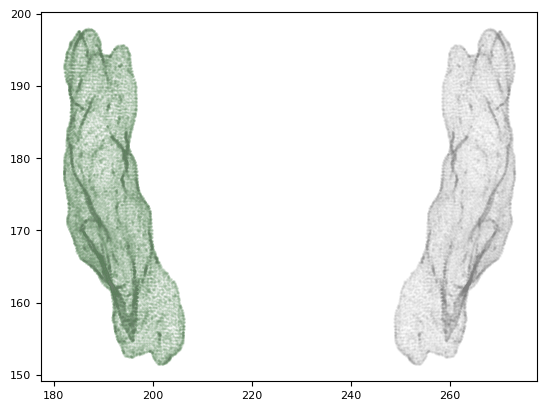

In [6]:

plt.scatter(mesh.vertices.T[2], mesh.vertices.T[1], c='green', s=1, alpha=0.05)
plt.scatter(mesh_mirror.vertices.T[2], mesh_mirror.vertices.T[1], c='gray', s=1, alpha=0.05)

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4747/951552937.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("D-V axis ($\mu$m)")
/tmp/ipykernel_4747/951552937.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel("A-P axis ($\mu$m)")
/tmp/ipykernel_4747/951552937.py:44: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel("M-L axis ($\mu$m)")


Saving figure to: /root/capsule/output/figures/merfish/cca.svg
Saving figure to: /root/capsule/output/figures/merfish/cca.png


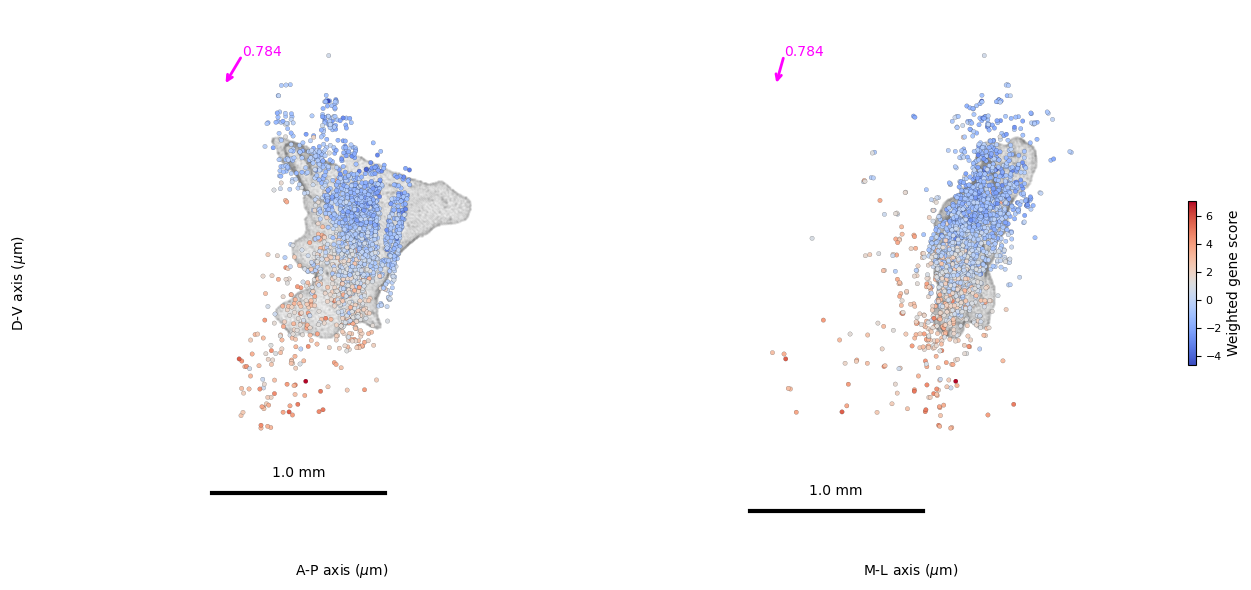

In [7]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,figsize=(13, 6),
    gridspec_kw={'width_ratios': [1, 1]},
    sharey=True)

# Sagittal view (A-P vs D-V)
ax1.scatter(mesh.vertices.T[0], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
plotting.scatter_with_jitter(ax1, allspatial_j, X_c[:, k], direction='s', s=s, lw=0.1,scl_jitter=0.05, ascending=False, cmap ='coolwarm')
ax1.margins(x=0.1, y=0.1)

# Add vector arrow
start_point_all = np.min(allspatial, 0)
start_point = (start_point_all[0], start_point_all[1])
end_point = (start_point_all[0] + vector_scaled[0], start_point_all[1] + vector_scaled[1])
ax1.annotate('',xy=end_point,xytext=start_point,arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax1.text(start_point[0], start_point[1], np.around(canonical_correlations[k], 3).astype(str), color='magenta')
ax1.invert_yaxis()
ax1.set_ylabel("D-V axis ($\mu$m)")
ax1.set_xlabel("A-P axis ($\mu$m)")
xt = ax1.get_xticks(); yt = ax1.get_yticks()
ax1.set_xticks(xt); ax1.set_yticks(yt)
ax1.set_xticklabels(plotting.format_ticklabels(xt, scale=25))
ax1.set_yticklabels(plotting.format_ticklabels(yt, scale=25))
plotting.draw_scale_bar(ax1, length_px=40, linewidth=3, px_to_mm=25/1000)
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)
    

# Coronal view (M-L vs D-V)
ax2.scatter(mesh.vertices.T[2], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
sca=plotting.scatter_with_jitter(ax2, allspatial_j, X_c[:, k], direction='c', s=s, lw=0.1,scl_jitter=0.05, ascending=False, cmap ='coolwarm')
ax2.margins(x=0.1, y=0.1)
cbar = plt.colorbar(sca, ax=ax2, label='Weighted gene score', shrink=0.3)

# Add vector arrow
start_point = (start_point_all[2], start_point_all[1])
end_point = (start_point_all[2] + vector_scaled[2], start_point_all[1] + vector_scaled[1])
ax2.annotate('',xy=end_point,xytext=start_point,arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax2.text(start_point[0], start_point[1], np.around(canonical_correlations[k], 3).astype(str), color='magenta')

# ax2.invert_yaxis()
ax2.set_xlabel("M-L axis ($\mu$m)")
xt = ax2.get_xticks(); yt = ax2.get_yticks()
ax2.set_xticks(xt); ax2.set_yticks(yt)
ax2.set_xticklabels(plotting.format_ticklabels(xt, scale=25))
ax2.set_yticklabels(plotting.format_ticklabels(yt, scale=25))
plotting.draw_scale_bar(ax2, length_px=40, linewidth=3, px_to_mm=25*1e-3)
ax2.set_xticks([])
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

ax1.set_aspect('equal', adjustable='datalim')
ax2.set_aspect('equal', adjustable='datalim')


fig.tight_layout()
save_figure("cca")
plt.show()

# which gene have weights

In [8]:
def analyze_gene_correlations_with_cca(adata_mer, cca, X_c, component_idx=1):
    """Find genes correlated with CCA components"""
    print(f"Analyzing gene correlations with CCA component {component_idx}...")
    
    # Get CCA component and gene weights
    w = cca.x_weights_[:, component_idx]
    genes = np.array(adata_mer.var_names)
    score = X_c[:, component_idx]
    
    # Convert sparse matrix if needed
    X = adata_mer.X
    if hasattr(X, 'toarray'):
        X = X.toarray()
    
    # Calculate Spearman correlations
    corrs = []
    for j in range(X.shape[1]):
        rho, _ = spearmanr(X[:, j], score)
        corrs.append(rho)
    
    # Create results DataFrame
    df_results = pd.DataFrame({
        "gene": genes,
        "gene_weight": w,
        "spearman_corr": corrs,
        "abs_corr": np.abs(corrs)
    }).sort_values("abs_corr", ascending=False)
    
    print(f"\nTop 10 genes by correlation with CCA component {component_idx+1}:")
    print(df_results.head(10))
    
    return df_results

# Analyze gene correlations
df_gene_corr = analyze_gene_correlations_with_cca(adata_mer, cca, X_c, component_idx=0)

Analyzing gene correlations with CCA component 0...

Top 10 genes by correlation with CCA component 1:
       gene  gene_weight  spearman_corr  abs_corr
269   Tacr3     0.184627       0.635200  0.635200
197    Pdyn    -0.162126      -0.579690  0.579690
163    Nefm     0.350100       0.555378  0.555378
44    Chodl    -0.149097      -0.505084  0.505084
183   Oprm1    -0.147513      -0.491991  0.491991
162    Nefl     0.208407       0.375168  0.375168
281    Trhr    -0.097945      -0.363756  0.363756
273      Th     0.045729       0.357773  0.357773
194  Pde11a    -0.088748      -0.350311  0.350311
99     Gad2    -0.106151      -0.322413  0.322413


Saving figure to: /root/capsule/output/figures/merfish/cca_top_genes_table.svg
Saving figure to: /root/capsule/output/figures/merfish/cca_top_genes_table.png


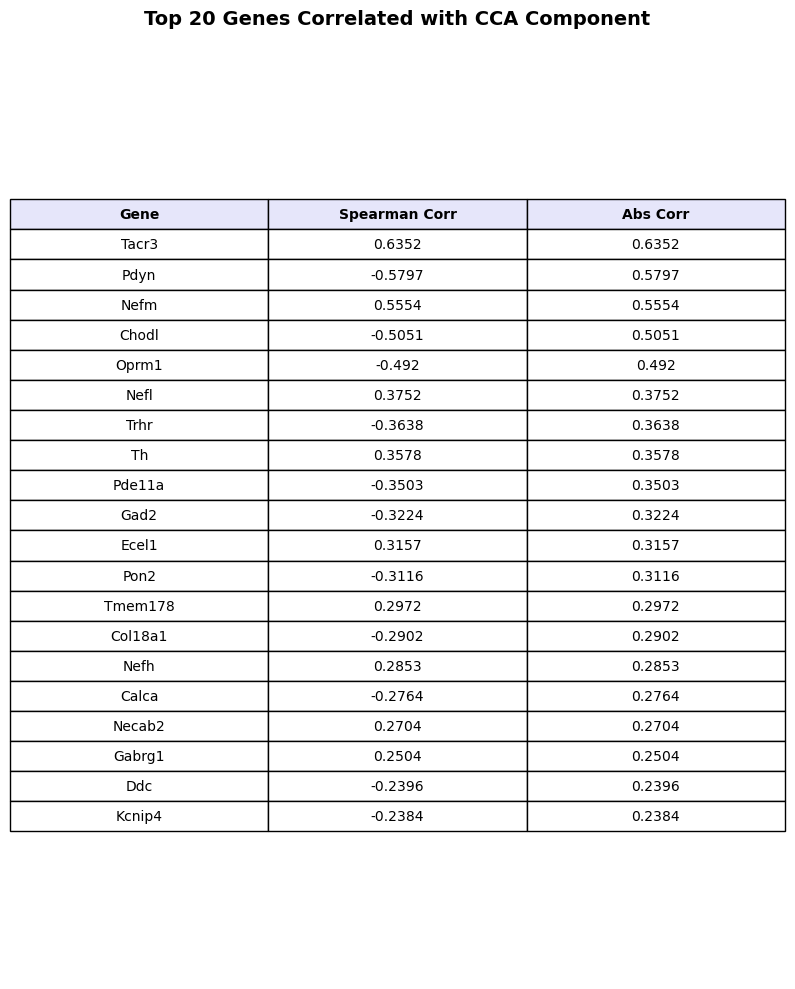

In [9]:
def create_gene_correlation_table(df_results, top_n=20):
    """Create and save a table of top correlated genes"""
    df_top = df_results.head(top_n)[['gene', 'spearman_corr', 'abs_corr']].copy()
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.axis("off")
    tbl = ax.table(
        cellText=df_top.round(4).values,
        colLabels=['Gene', 'Spearman Corr', 'Abs Corr'],
        loc="center",
        cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.5)
    
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor('#E6E6FA')
    
    plt.title(f'Top {top_n} Genes Correlated with CCA Component', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    save_figure("cca_top_genes_table")
    plt.show()

# Create correlation table
create_gene_correlation_table(df_gene_corr)

# visualize these genes in space

In [10]:
def create_colormaps(base_cmap_name=CMAP_NAME):
    """Create colormap configurations for gene visualization."""
    from matplotlib.colors import LinearSegmentedColormap    
    cmap_sele = plt.get_cmap(base_cmap_name)
    low_col = cmap_sele(0.0)   # RGBA for the "bottom" color
    high_col = cmap_sele(1.0)  # RGBA for the "top" color
    low_cmap = LinearSegmentedColormap.from_list("low_cmap", ["white", low_col])
    high_cmap = LinearSegmentedColormap.from_list("high_cmap", ["white", high_col])
    return low_col, high_col, low_cmap, high_cmap

low_col, high_col, low_cmap, high_cmap = create_colormaps()

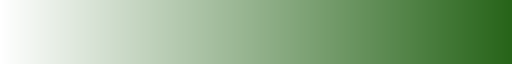

In [11]:
high_cmap

In [12]:
from matplotlib.gridspec import GridSpec

def plot_one_gene(adata_mer, gene, mesh, is_lowgene, colors=None, s=3):
    if colors is None:
        colors = [high_col, low_col]
        cmapnames = [high_cmap, low_cmap]

    if is_lowgene:
        cmap_use = low_cmap
        col_use = low_col
    else:
        cmap_use = high_cmap
        col_use = high_col

    fig = plt.figure(figsize=(14, 3.2))
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.05], wspace=0.08)

    axes = np.empty((1, 2), dtype=object)
    axes[0, 0] = fig.add_subplot(gs[0, 0])
    axes[0, 1] = fig.add_subplot(gs[0, 1], sharey=axes[0, 0])

    plotorder = np.argsort(adata_mer[:, gene].X.flatten())
    vals = cpm_scl * adata_mer[:, gene].X.toarray().flatten()

    # left: sagittal
    axL = axes[0, 0]
    axL.scatter(mesh.vertices[:, 0], mesh.vertices[:, 1], c='gray', s=1, alpha=0.05)
    plotting.scatter_with_jitter(
        axL,
        allspatial_j_ML[plotorder],
        vals[plotorder],
        direction='s',
        s=s,
        lw=0.05,
        ascending=True,
        cmap=cmap_use
    )
    axL.set_aspect('equal', adjustable='box')
    axL.set_ylabel("D-V axis")
    axL.set_xlabel("A-P axis")
    axL.set_xticks([])
    axL.set_yticks([])
    for spine in axL.spines.values():
        spine.set_visible(False)

    # right: coronal
    axR = axes[0, 1]
    axR.scatter(mesh_mirror.vertices[:, 2], mesh_mirror.vertices[:, 1], c='gray', s=1, alpha=0.05)
    sca = plotting.scatter_with_jitter(
        axR,
        allspatial_j_ML[plotorder],
        vals[plotorder],
        direction='c',
        s=s,
        lw=0.05,
        ascending=True,
        cmap=cmap_use
    )
    axR.set_aspect('equal', adjustable='box')
    axR.set_xlabel("M-L axis")
    axR.set_xticks([])
    axR.set_yticks([])
    for spine in axR.spines.values():
        spine.set_visible(False)

    # separate colorbar axis
    cax = fig.add_subplot(gs[0, 2])
    cbar = fig.colorbar(sca, cax=cax)
    cbar.ax.set_title(gene, color=col_use, pad=6, fontsize=10)

    # force common inverted ylim across both panels
    ymins, ymaxs = [], []
    for ax in axes.ravel():
        lo, hi = ax.get_ylim()
        ymins.append(min(lo, hi))
        ymaxs.append(max(lo, hi))

    common_lo = min(ymins)
    common_hi = max(ymaxs)
    for ax in axes.ravel():
        ax.set_ylim(common_hi, common_lo)

    return fig

In [13]:
G = 10
print("Visualizing high-corr genes...")

highcorgenes = df_gene_corr[:G].gene.values.tolist()
lowgenes = df_gene_corr[:G]['spearman_corr'].values > 0

for gene, is_lowgene in zip(highcorgenes, lowgenes):
    fig = plot_one_gene(adata_mer, gene, mesh, is_lowgene)
    save_figure(f"high_corr_gene_spatial_{gene}")
    plt.show()
    plt.close(fig)

Visualizing high-corr genes...


NameError: name 'GridSpec' is not defined

<Figure size 1400x320 with 0 Axes>

# Visualize canonical variables on UMAP


In [ ]:
# Visualize canonical variables on UMAP embedding
print("Visualizing canonical variables on UMAP...")
s = 10
fs = 10
plt.figure(figsize=(7, 5))
ax = plt.gca()

sca = ax.scatter(adata_mer.obsm['X_umap'][:, 0], adata_mer.obsm['X_umap'][:, 1], 
                c=X_c[:, k], cmap='coolwarm', s=s, edgecolor='k', linewidth=0.1)
ax.set_aspect('equal')    
cbar = plt.colorbar(sca, ax=ax, label='Weighted gene score', shrink=0.3)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.invert_yaxis()

# Add UMAP axis labels
y0, x0 = np.min(adata_mer.obsm['X_umap'], 0)
y0 *= 1.4
x0 *= 0.8
ax.arrow(x0, y0, 1, 0, head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='k')
ax.arrow(x0, y0, 0, 1, head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='black')

ax.text(x0+1.05, y0, 'UMAP 1', va='center', ha='left', fontsize=fs)
ax.text(x0, y0+1.6, 'UMAP 2', va='bottom', ha='center', fontsize=fs)
plt.tight_layout()
save_figure("merfish_umap")
plt.show()

# Find Genes Correlated with CCA Direction


In [ ]:
# Find genes correlated with the CCA direction
print("Finding genes correlated with CCA direction...")
direction_of_interest = -cca.y_weights_[:, 0]
direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
projected = adata_mer.obsm['spatial'] @ direction_norm

# Convert sparse matrix to numpy array if needed
if hasattr(adata_mer.X, 'toarray'):
    X = adata_mer.X.toarray()
else:
    X = np.array(adata_mer.X)

gene_names = adata_mer.var_names
results = []
for i, gene in enumerate(gene_names):
    expr = X[:, i]
    corr, pval = spearmanr(expr, projected)
    results.append((gene, corr, pval))

df_results = pd.DataFrame(results, columns=['gene', 'spearman_corr', 'p_value'])
df_results_sorted = df_results.sort_values(by='spearman_corr', key=lambda s: s.abs(), ascending=False)

print("Top 10 correlated genes:")
print(df_results_sorted.head(10))

# Gene Imputation and Visualization

In [ ]:
def load_and_impute_data(adata_mer, snrna_data_path, k=200, n_hvg=None):
    """Load scRNA-seq data and impute MERFISH gene expression."""
    print("Loading scRNA-seq data for imputation...")
    adata_foo = sc.read_h5ad(snrna_data_path)
    adata_sc = sc.AnnData(adata_foo.layers['BN'])
    adata_sc.obs = adata_foo.obs.copy()
    adata_sc.obsm = adata_foo.obsm.copy()
    adata_sc.var = adata_foo.var.copy()

    # Subset MERFISH data to match genes in scRNA-seq
    var_names = adata_mer.var_names.intersection(adata_sc.var_names)
    adata_mer_foo = adata_mer[:, var_names]
    print(f"Number of shared genes for imputation: {len(var_names)}")

    # Impute MERFISH data
    print("Imputing gene expression data...")
    adata_mer_imputed = imputations.impute_mer_data(adata_sc, adata_mer_foo, k=k, n_hvg=n_hvg, 
                                                    similarity_transform = 'softmax')
    adata_mer_imputed.obsm['spatial'] = adata_mer.obsm['spatial'].copy()
    
    return adata_mer_imputed, adata_sc

# Load and impute data
snrna_data_path = os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_merbar_1-5k.h5ad")
adata_mer_imputed, adata_sc = load_and_impute_data(adata_mer, snrna_data_path)

# Visualize Selected Genes in Spatial Coordinates

In [ ]:
from matplotlib.gridspec import GridSpec

def plot_selected_genes(adata_imputed, selected_genes, mesh, colors=None, s=3):
    if colors is None:
        colors = [high_col, low_col]
        cmapnames = [high_cmap, low_cmap]

    n = len(selected_genes)
    fig = plt.figure(figsize=(14, 3.2 * n))
    gs = GridSpec(n, 3, figure=fig, width_ratios=[1, 1, 0.05], wspace=0.08, hspace=0.15)

    axes = np.empty((n, 2), dtype=object)

    # first pass: make axes
    for k in range(n):
        axes[k, 0] = fig.add_subplot(gs[k, 0])
        if k == 0:
            axes[k, 1] = fig.add_subplot(gs[k, 1], sharey=axes[k, 0])
        else:
            axes[k, 1] = fig.add_subplot(gs[k, 1], sharey=axes[0, 0])

    for k, gene in enumerate(selected_genes):
        vals = CPM_SCL * adata_imputed[:, gene].X.toarray().flatten()
        plotorder = np.argsort(vals)

        # left
        axL = axes[k, 0]
        axL.scatter(mesh.vertices[:, 0], mesh.vertices[:, 1], c='gray', s=1, alpha=0.05)
        plotting.scatter_with_jitter(
            axL,
            allspatial_j_ML[plotorder],
            vals[plotorder],
            direction='s',
            s=s,
            lw=0.1,
            ascending=False,
            cmap=cmapnames[k]
        )
        axL.set_aspect('equal', adjustable='box')
        axL.set_ylabel("D-V axis")
        axL.set_xlabel("A-P axis" if k == n - 1 else "")
        axL.set_xticks([])
        axL.set_yticks([])
        # axL.invert_yaxis()
        for spine in axL.spines.values():
            spine.set_visible(False)

        # right
        axR = axes[k, 1]
        axR.scatter(mesh_mirror.vertices[:, 2], mesh_mirror.vertices[:, 1], c='gray', s=1, alpha=0.05)
        sca = plotting.scatter_with_jitter(
            axR,
            allspatial_j_ML[plotorder],
            vals[plotorder],
            direction='c',
            s=s,
            lw=0.1,
            ascending=False,
            cmap=cmapnames[k]
        )
        axR.set_aspect('equal', adjustable='box')
        axR.set_xlabel("M-L axis" if k == n - 1 else "")
        axR.set_xticks([])
        axR.set_yticks([])
        # axR.invert_yaxis()
        for spine in axR.spines.values():
            spine.set_visible(False)

        # colorbar in separate axis
        cax = fig.add_subplot(gs[k, 2])
        cbar = fig.colorbar(sca, cax=cax)
        cbar.ax.set_title(gene, color=colors[k], pad=6, fontsize=10)

    # optional: force a common ylim explicitly
    ymins, ymaxs = [], []
    for ax in axes.ravel():
        lo, hi = ax.get_ylim()
        ymins.append(min(lo, hi))
        ymaxs.append(max(lo, hi))

    common_lo = min(ymins)
    common_hi = max(ymaxs)
    for ax in axes.ravel():
        ax.set_ylim(common_hi, common_lo)

    return fig

    
print("Visualizing selected genes...")
selected_genes = ['Epha6', 'Chsy3']
fig = plot_selected_genes(adata_mer_imputed, selected_genes, mesh)
save_figure("two_genes_examples")
plt.show()

# Generate Heatmap of Gene Expression


In [ ]:
def create_gene_expression_heatmap(adata_imputed, cca, output_dir, gene_list_file='allyourgenes.pkl'):
    """Create a heatmap of gene expression ordered by CCA direction."""
    import pickle
    import os
    import numpy as np
    k = 0
    direction_of_interest = cca.y_weights_[:, k]
    direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
    projected = adata_mer.obsm['spatial'] @ direction_norm
    # Load metadata from first notebook
    output_file = os.path.join(output_dir, gene_list_file)
    payload = pickle.load(open(output_file, 'rb'))
    genes_clustered = payload["genes_clustered"]   # order used in scRNA heatmap
    genes_original  = payload["genes_original"]    # pos + neg + U concatenated
    n_pos           = payload["n_pos"]
    n_neg           = payload["n_neg"]
    n_u             = payload["n_u"]
    # Use the clustered order, but keep only genes that exist in MERFISH
    available_genes = [g for g in genes_clustered if g in adata_imputed.var_names]

    # Sort cells by position along the CCA direction
    t_order = np.argsort(projected)

    # Build heatmap matrix: genes x cells
    inputheatmap = adata_imputed[:, available_genes].X.toarray()[t_order].T

    # No reordering of genes here (we already use scRNA-clustered order)
    ordered_data, row_order = heatmap.get_final_heatmap(
        inputheatmap,
        gene_reorder=False
    )
    # Compute tick colors via original category membership
    tick_colors = []
    for orig_idx in row_order:
        g = available_genes[orig_idx]
        # Map back to original concatenated list to see which block it came from
        original_position = genes_original.index(g)
        if original_position < n_pos:
            # Positive genes block
            tick_colors.append(high_col)
        elif original_position < n_pos + n_u:
            # u-genes genes block
            tick_colors.append('gray')
        else:
            # nagative genes
            tick_colors.append(low_col)

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    print("Creating gene expression heatmap...")
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        ordered_data.T,
        cmap='Greys',
        cbar_kws={
            'location': 'top',
            'label': 'Relative expression',
            'shrink': 0.3,
            'aspect': 2,
            'fraction': 0.1
        }
    )

    ax = plt.gca()

    # xticks + colors (match your scRNA heatmap style)
    xtick_labels = [available_genes[l] for l in row_order]   # len = n_genes
    n_genes = len(xtick_labels)
    xtick_positions = np.arange(n_genes) + 0.5               # centers of cells

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, rotation=90)

    for tick, color in zip(ax.get_xticklabels(), tick_colors):
        tick.set_color(color)

    plt.ylabel('Location on DV axis')
    q = 2  # How many labels to show on y-axis
    plt.yticks(
        np.arange(q) * (ordered_data.shape[1] // (q - 1)) + 0.5,
        ['Dorsal', 'Ventral'],
        rotation=0
    )
    plt.grid(False)
    plt.tight_layout()
    return plt.gcf()

# Create heatmap
fig = create_gene_expression_heatmap(adata_mer_imputed, cca, TMP_OUT_DIR)
save_figure("merfish_heatmap")
plt.show()


# Impute Pseudoclusters from scRNAseq to MERFISH

In [ ]:
def run_impute_pseudoclusters(adata_mer, adata_sc, output_dir, k=100):
    """Impute pseudoclusters from scRNA-seq to MERFISH data."""
    print("Imputing pseudoclusters...")
    common_genes_mer = np.intersect1d(adata_mer.var_names, adata_sc.var_names)
    adata_mer_subset = adata_mer[:, common_genes_mer]

    imp_mer, conf_mer = imputations.impute_pseudocluster(
        adata_mer_subset, adata_sc, pc_dir=output_dir, k=k,  
        similarity_transform = 'softmax')#, similarity_kwargs={'sigma': 0.1})
    adata_mer.obs['imputed pseudocluster'] = imp_mer
    return imp_mer, conf_mer

imp_mer, conf_mer = run_impute_pseudoclusters(adata_mer, adata_sc, TMP_OUT_DIR, k=100)

In [ ]:
def plot_pseudoclusters(adata_mer, allspatial_j, mesh, s=10, scl_jitter=0.05, save_name="merfish_pc"):
    
    """Plot imputed pseudoclusters in spatial coordinates."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), 
                                   gridspec_kw={'width_ratios': [1, 1]}, sharey=True)
    
    # ——— Left: Sagittal view (direction='s') ———
    plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax1, allspatial_j, adata_mer.obs['imputed pseudocluster'], vmin=0, vmax = 1,
                                 direction='s', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap='PiYG')
    ax1.set_ylabel("D–V axis")
    ax1.set_xlabel("A–P axis")
    ax1.set_xticks([]); ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)

    # ——— Right: Coronal view (direction='c') ———
    plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax2, allspatial_j, adata_mer.obs['imputed pseudocluster'], vmin=0, vmax = 1,
                                 direction='c', s=s, lw=0.1, scl_jitter=scl_jitter, ascending=True, cmap='PiYG')
    cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("Pseudoclusters\n(imputed)", ha='center', va='bottom')
    ax2.set_xlabel("M–L axis")
    ax2.set_xticks([]); ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)
    ax1.set_aspect('equal', adjustable='datalim')
    ax2.set_aspect('equal', adjustable='datalim')    
    fig.tight_layout()
    ax1.invert_yaxis()
    save_figure(save_name)
    return fig

# Plot pseudoclusters
fig = plot_pseudoclusters(adata_mer, allspatial_j,mesh)
plt.show()

In [ ]:
def plot_confidence_metrics(adata_mer, allspatial_j,conf_mer, mesh, s=10, scl_jitter=0.05):
    """Plot confidence interval width and confidence power for pseudocluster imputation."""
    # Calculate and store confidence interval width
    ci_width = conf_mer['ci_range']
    adata_mer.obs['pc_ci_width'] = ci_width

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), 
                                   gridspec_kw={'width_ratios': [1, 1]}, sharey=True)
    plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
    plotting.scatter_with_jitter(ax1, allspatial_j, ci_width, direction='s', lw=0.1, s=s, ascending=True, cmap='bwr')
    ax1.set_ylabel("D–V axis")
    ax1.set_xlabel("A–P axis")
    ax1.set_xticks([]); ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)

    plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax2, allspatial_j, ci_width, direction='c', lw=0.1, s=s,ascending=True, cmap='bwr')
    cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("CI width\n(95%)", ha='center')
    ax2.set_aspect('equal')
    ax2.set_xlabel("M–L axis")
    ax2.set_xticks([]); ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)
    ax1.set_aspect('equal', adjustable='datalim')
    ax2.set_aspect('equal', adjustable='datalim')    
    fig.tight_layout()
    ax1.invert_yaxis()
    save_figure("merfish_pc_CI")
    plt.show()    
    return fig

# Plot confidence metrics
fig = plot_confidence_metrics(adata_mer, allspatial_j,conf_mer, mesh)

In [ ]:
def plot_confidence_power(conf_mer, allspatial_j,mesh, s=10, scl_jitter=0.05):
    """Plot confidence power for pseudocluster imputation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), 
                                   gridspec_kw={'width_ratios': [1, 1]}, sharey=True)    
    plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
    plotting.scatter_with_jitter(ax1, allspatial_j, conf_mer['conf_power'], direction='s', lw=0.1, s=s, ascending=True)
    ax1.set_ylabel("D–V axis")
    ax1.set_xlabel("A–P axis")
    ax1.set_xticks([]); ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)

    plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax2, allspatial_j, conf_mer['conf_power'], direction='c', lw=0.1, s=s, ascending=True)
    cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("Confidence\npower", ha='center', va='bottom')
    ax2.set_xlabel("M–L axis")
    ax2.set_xticks([]); ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)
        
    ax1.set_aspect('equal', adjustable='datalim')
    ax2.set_aspect('equal', adjustable='datalim')    
    fig.tight_layout()
    ax1.invert_yaxis()
    plt.show()
    # save_figure("merfish_confidence")
    return fig

# Plot confidence power
fig = plot_confidence_power(conf_mer, allspatial_j,mesh)
plt.show()

In [ ]:
def plot_pseudocluster_std(conf_mer,allspatial_j,mesh, s=10, scl_jitter=0.05):
    """Plot pseudocluster standard deviation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), 
                                   gridspec_kw={'width_ratios': [1, 1]}, sharey=True)    
    plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
    plotting.scatter_with_jitter(ax1, allspatial_j, conf_mer['pc_std'], direction='s', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap='BrBG')
    ax1.set_ylabel("D–V axis")
    ax1.set_xlabel("A–P axis")
    ax1.set_xticks([]); ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)

    plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax2, allspatial_j, conf_mer['pc_std'], direction='c', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap='BrBG')
    cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("Pseudocluster\nstd", ha='center', va='bottom')
    ax2.set_xlabel("M–L axis")
    ax2.set_xticks([]); ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)
        
    ax1.set_aspect('equal', adjustable='datalim')
    ax2.set_aspect('equal', adjustable='datalim')    
    fig.tight_layout()
    ax1.invert_yaxis()
    save_figure("merfish_pc_std")
    return fig

# Plot pseudocluster standard deviation
fig = plot_pseudocluster_std(conf_mer, allspatial_j,mesh)
plt.show()


# scatter plot (btw DV axis and pseudocluster score)

In [ ]:
corrcoeff_dv_pc = np.corrcoef( adata_mer.obs['imputed pseudocluster'],allspatial_j[:,1])[0,1]

plt.scatter( adata_mer.obs['imputed pseudocluster'] ,allspatial_j[:,1], s=1)
plt.title(f'r={np.around(corrcoeff_dv_pc,2)}')
plt.xlabel('imputed pseudoclusters')
plt.ylabel('DV axis coords')

In [ ]:
# direction_of_interest = -cca.y_weights_[:, 1]
# direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
# projected = adata_mer.obsm['spatial'] @ direction_norm


corrcoeff_dv_pc = np.corrcoef(adata_mer.obs['imputed pseudocluster'],projected)[0,1]

plt.scatter(adata_mer.obs['imputed pseudocluster'], projected,s=1)
plt.title(f'r={np.around(corrcoeff_dv_pc,2)}')
plt.xlabel('imputed pseudoclusters')
plt.ylabel('vector projection')

# Visualize Retroseq DE Genes
(removed because theres really no DE genes in retroseq data)


# complete!

In [ ]:
print("Analysis complete! All visualizations have been saved to:", fig_path)

In [ ]:
fig_path
